# ML Engineering & Ops

Feedback momenten:
- Week 6 – datapipeline onderdeel
- Week 12 – modelleren en model tracking
- Week 17 – deployment

## 1 Inleiding

## 2 Probleemstelling en doel

## imports

In [37]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

## Configuratie

In [38]:
@dataclass
class Config:
    bitext_path: str = "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
    twitter_sample_path: str = "sample.csv"
    twitter_full_path: str = "twcs.csv"

    output_dir: Path = Path("flowsure_artifacts")
    random_state: int = 42
    max_twitter_rows: int = 50000


config = Config()
config.output_dir.mkdir(exist_ok=True)

## Data inlezen

In [39]:
import pandas as pd

bitext_df = pd.read_csv(config.bitext_path)

twitter_sample_df = pd.read_csv(
    config.twitter_sample_path
)

twitter_df = pd.read_csv(
    config.twitter_full_path,
    nrows=config.max_twitter_rows
)

print("Bitext:", bitext_df.shape)
print("Twitter sample:", twitter_sample_df.shape)
print("Twitter full:", twitter_df.shape)

Bitext: (26872, 5)
Twitter sample: (93, 7)
Twitter full: (50000, 7)


In [40]:
display(bitext_df.head())
display(twitter_df.head())

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


## data inspecteren

In [41]:
print("Bitext kolommen:")
print(bitext_df.columns)

print("\nTwitter kolommen:")
print(twitter_df.columns)

print("\nBitext missende waarden:")
print(bitext_df.isna().sum())

print("\nTwitter missende waarden:")
print(twitter_df.isna().sum())

Bitext kolommen:
Index(['flags', 'instruction', 'category', 'intent', 'response'], dtype='object')

Twitter kolommen:
Index(['tweet_id', 'author_id', 'inbound', 'created_at', 'text',
       'response_tweet_id', 'in_response_to_tweet_id'],
      dtype='object')

Bitext missende waarden:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Twitter missende waarden:
tweet_id                       0
author_id                      0
inbound                        0
created_at                     0
text                           0
response_tweet_id          16558
in_response_to_tweet_id    12916
dtype: int64


## tekst opschonen

In [42]:
def clean_text(text):
    """Schoon supporttekst op voor ML-training."""
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"{{.*?}}", " PLACEHOLDER ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

## Bitex voorbereiden voor edge model

In [43]:
bitext_clean = bitext_df.copy()

bitext_clean["text_clean"] = bitext_clean["instruction"].apply(clean_text)
bitext_clean["category"] = bitext_clean["category"].astype(str)
bitext_clean["intent"] = bitext_clean["intent"].astype(str)

bitext_clean = bitext_clean[
    bitext_clean["text_clean"].str.len() > 5
].drop_duplicates(subset=["text_clean"])

print(bitext_clean.shape)
display(bitext_clean.head())

(23826, 6)


,flags,instruction,category,intent,response,text_clean
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...,question about cancelling order PLACEHOLDER
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...,i have a question about cancelling oorder PLAC...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...,i need help cancelling puchase PLACEHOLDER
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...,i need to cancel purchase PLACEHOLDER
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...,i cannot afford this order cancel purchase PLA...


## train/tesst split

In [44]:
X = bitext_clean["text_clean"]
y = bitext_clean["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=config.random_state,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (19060,)
Test: (4766,)


## Edge model trainen

In [45]:
edge_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=15000,
                ngram_range=(1, 2),
                min_df=2
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=config.random_state
            )
        )
    ]
)

edge_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=15000, min_df=2,
                                 ngram_range=(1, 2))),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## Evaluatie edge model

In [46]:
y_pred = edge_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9979
Macro F1: 0.9985

Classification report:
              precision    recall  f1-score   support

     ACCOUNT       1.00      1.00      1.00      1015
      CANCEL       1.00      1.00      1.00       186
     CONTACT       1.00      1.00      1.00       389
    DELIVERY       1.00      1.00      1.00       324
    FEEDBACK       1.00      1.00      1.00       398
     INVOICE       1.00      1.00      1.00       357
       ORDER       1.00      0.99      1.00       603
     PAYMENT       0.99      0.99      0.99       396
      REFUND       1.00      1.00      1.00       512
    SHIPPING       1.00      1.00      1.00       390
SUBSCRIPTION       1.00      1.00      1.00       196

    accuracy                           1.00      4766
   macro avg       1.00      1.00      1.00      4766
weighted avg       1.00      1.00      1.00      4766



## Confusion matrix

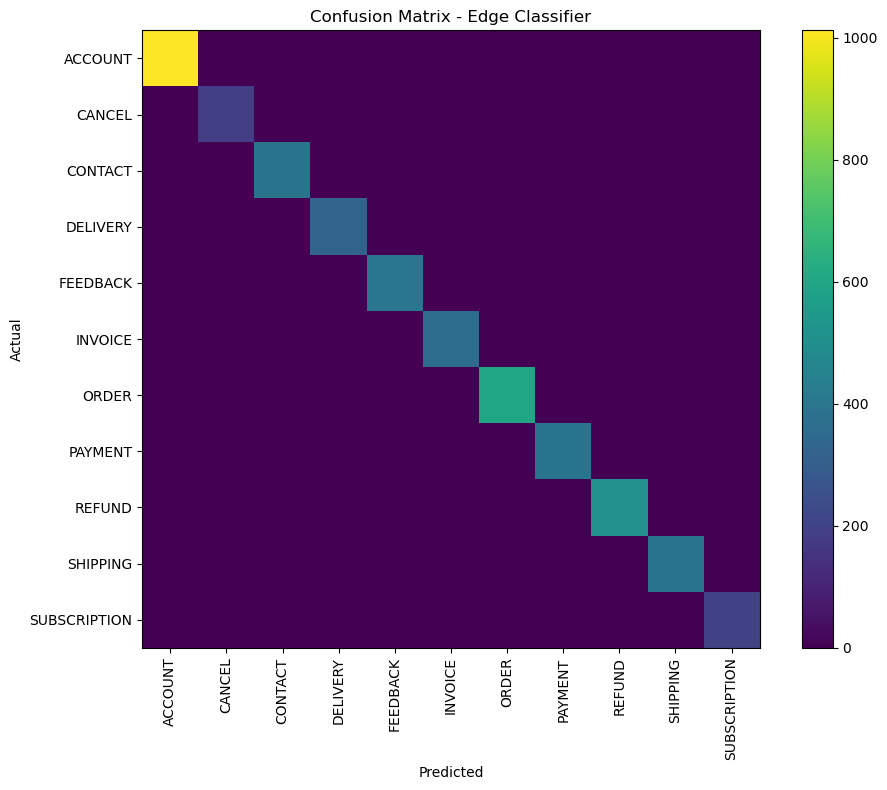

In [47]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix - Edge Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## Intentmodel trainen

In [48]:
X_intent = bitext_clean["text_clean"]
y_intent = bitext_clean["intent"]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_intent,
    y_intent,
    test_size=0.2,
    random_state=config.random_state,
    stratify=y_intent
)

intent_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=config.random_state
            )
        )
    ]
)

intent_model.fit(X_train_i, y_train_i)

intent_pred = intent_model.predict(X_test_i)

print("Intent Accuracy:", accuracy_score(y_test_i, intent_pred))
print("Intent Macro F1:", f1_score(y_test_i, intent_pred, average="macro"))
print(classification_report(y_test_i, intent_pred))

Intent Accuracy: 0.9918170373478808
Intent Macro F1: 0.9911067723796991
                          precision    recall  f1-score   support

            cancel_order       0.96      0.95      0.96        84
            change_order       0.95      0.99      0.97       169
 change_shipping_address       0.99      0.99      0.99       192
  check_cancellation_fee       1.00      1.00      1.00       186
           check_invoice       0.96      1.00      0.98       182
   check_payment_methods       0.99      0.99      0.99       198
     check_refund_policy       1.00      1.00      1.00       194
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.96      0.98       195
     contact_human_agent       0.96      0.99      0.98       194
          create_account       1.00      0.99      1.00       161
          delete_account       0.99      1.00      1.00       171
        delivery_options       0.99      1.00      1.00       126
   

## Twitter data als inkomende tickets gebruiken
Twitter heeft geen labels, dus gebruik je het als realistische inkomende supporttickets.

In [49]:
twitter_clean = twitter_df.copy()

twitter_clean = twitter_clean[twitter_clean["inbound"] == True]
twitter_clean["text_clean"] = twitter_clean["text"].apply(clean_text)

twitter_clean = twitter_clean[
    twitter_clean["text_clean"].str.len() > 5
].drop_duplicates(subset=["text_clean"])

print(twitter_clean.shape)
display(twitter_clean.head())

(26299, 8)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,text_clean
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,USER and how do you propose we do that
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0,USER i have sent several private messages and ...
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0,USER i did
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN,USER is the worst customer service
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15.0,USER you gonna magically change your connectiv...


## Classificatie toepassen op Twitter tickets

In [50]:
twitter_clean["predicted_category"] = edge_model.predict(
    twitter_clean["text_clean"]
)

twitter_clean["predicted_intent"] = intent_model.predict(
    twitter_clean["text_clean"]
)

display(
    twitter_clean[
        ["tweet_id", "author_id", "text", "predicted_category", "predicted_intent"]
    ].head(10)
)

,tweet_id,author_id,text,predicted_category,predicted_intent
1,2,115712,@sprintcare and how do you propose we do that,ACCOUNT,edit_account
2,3,115712,@sprintcare I have sent several private messag...,ACCOUNT,place_order
4,5,115712,@sprintcare I did.,ACCOUNT,edit_account
6,8,115712,@sprintcare is the worst customer service,CONTACT,contact_customer_service
8,12,115713,@sprintcare You gonna magically change your co...,ACCOUNT,edit_account
10,16,115713,@sprintcare Since I signed up with you....Sinc...,ACCOUNT,registration_problems
12,18,115713,@115714 y’all lie about your “great” connectio...,ACCOUNT,review
14,20,115715,"@115714 whenever I contact customer support, t...",ACCOUNT,contact_customer_service
16,22,115716,@Ask_Spectrum Would you like me to email you a...,ACCOUNT,edit_account
18,26,115716,@Ask_Spectrum I received this from your corpor...,SUBSCRIPTION,newsletter_subscription


## Prioriteit bepalen met simpele business rules

In [51]:
def assign_priority(text):
    """Bepaal ticketprioriteit op basis van woorden."""
    text = text.lower()

    high_keywords = [
        "urgent", "asap", "down", "error", "crash",
        "not working", "broken", "refund", "charged"
    ]

    medium_keywords = [
        "problem", "issue", "can't", "cannot",
        "help", "failed", "missing"
    ]

    if any(word in text for word in high_keywords):
        return "high"

    if any(word in text for word in medium_keywords):
        return "medium"

    return "low"


twitter_clean["priority"] = twitter_clean["text"].apply(assign_priority)

display(
    twitter_clean[
        ["text", "predicted_category", "predicted_intent", "priority"]
    ].head(10)
)

,text,predicted_category,predicted_intent,priority
1,@sprintcare and how do you propose we do that,ACCOUNT,edit_account,low
2,@sprintcare I have sent several private messag...,ACCOUNT,place_order,low
4,@sprintcare I did.,ACCOUNT,edit_account,low
6,@sprintcare is the worst customer service,CONTACT,contact_customer_service,low
8,@sprintcare You gonna magically change your co...,ACCOUNT,edit_account,low
10,@sprintcare Since I signed up with you....Sinc...,ACCOUNT,registration_problems,low
12,@115714 y’all lie about your “great” connectio...,ACCOUNT,review,low
14,"@115714 whenever I contact customer support, t...",ACCOUNT,contact_customer_service,low
16,@Ask_Spectrum Would you like me to email you a...,ACCOUNT,edit_account,low
18,@Ask_Spectrum I received this from your corpor...,SUBSCRIPTION,newsletter_subscription,low


## routering naar support squad

In [52]:
def route_ticket(category):
    """Routeer ticket naar juiste squad."""
    category = category.upper()

    routing = {
        "ORDER": "Order Support Squad",
        "ACCOUNT": "Account Support Squad",
        "PAYMENT": "Billing Squad",
        "REFUND": "Billing Squad",
        "CONTACT": "General Support Squad",
        "FEEDBACK": "Customer Success Squad",
        "DELIVERY": "Logistics Squad"
    }

    return routing.get(category, "General Support Squad")


twitter_clean["assigned_squad"] = twitter_clean["predicted_category"].apply(
    route_ticket
)

display(
    twitter_clean[
        ["text", "predicted_category", "priority", "assigned_squad"]
    ].head(10)
)

,text,predicted_category,priority,assigned_squad
1,@sprintcare and how do you propose we do that,ACCOUNT,low,Account Support Squad
2,@sprintcare I have sent several private messag...,ACCOUNT,low,Account Support Squad
4,@sprintcare I did.,ACCOUNT,low,Account Support Squad
6,@sprintcare is the worst customer service,CONTACT,low,General Support Squad
8,@sprintcare You gonna magically change your co...,ACCOUNT,low,Account Support Squad
10,@sprintcare Since I signed up with you....Sinc...,ACCOUNT,low,Account Support Squad
12,@115714 y’all lie about your “great” connectio...,ACCOUNT,low,Account Support Squad
14,"@115714 whenever I contact customer support, t...",ACCOUNT,low,Account Support Squad
16,@Ask_Spectrum Would you like me to email you a...,ACCOUNT,low,Account Support Squad
18,@Ask_Spectrum I received this from your corpor...,SUBSCRIPTION,low,General Support Squad


## conceptantwoord genereen met Bitext response lookup
Ticket
→ voorspelde intent/categorie
→ relevante Bitext responses ophalen als context
→ generatief model maakt nieuw conceptantwoord

In [53]:
%pip install transformers torch sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [54]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

tokenizer = AutoTokenizer.from_pretrained(
    "google/flan-t5-small"
)

cloud_model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-small"
)

print("Cloud model loaded")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Cloud model loaded


In [78]:
def generate_cloud_response(ticket_text, predicted_intent, knowledge_df):
    context_rows = knowledge_df[
        knowledge_df["intent"] == predicted_intent
    ].head(3)

    if len(context_rows) == 0:
        return (
            "Thank you for contacting support. "
            "A support agent will review your request and get back to you shortly."
        )

    best_example_response = str(context_rows["response"].iloc[0])

    prompt = (
        "Write a customer support reply.\n"
        f"Message: {ticket_text}\n"
        f"Intent: {predicted_intent}\n"
        f"Example reply: {best_example_response}\n"
        "Reply:"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    outputs = cloud_model.generate(
    **inputs,
    max_new_tokens=60,
    num_beams=5,
    no_repeat_ngram_size=3,
    repetition_penalty=2.5,
    early_stopping=True
)
    

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    bad_output = (
        len(response.split()) < 6
        or "customer message" in response.lower()
        or "message:" in response.lower()
        or "intent:" in response.lower()
        or response.lower() == ticket_text.lower()
        or response.lower() in [
            "be professional",
            "be polite",
            "reply",
            "support response"
        ]
    )

    if bad_output:
        response = best_example_response
    
    response = response.replace(
    "{{Order Number}}",
    "[Order Number]"
)

    return response

In [79]:
test_ticket = "I want to cancel my order because I ordered the wrong item."

test_response = generate_cloud_response(
    test_ticket,
    "cancel_order",
    bitext_clean
)

print("Customer message:")
print(test_ticket)

print("\nAI draft response:")
print(test_response)

Customer message:
I want to cancel my order because I ordered the wrong item.

AI draft response:
I've understood you have a question regarding canceling order [Order Number], and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.


##  monitoringdashboard: volume per categorie

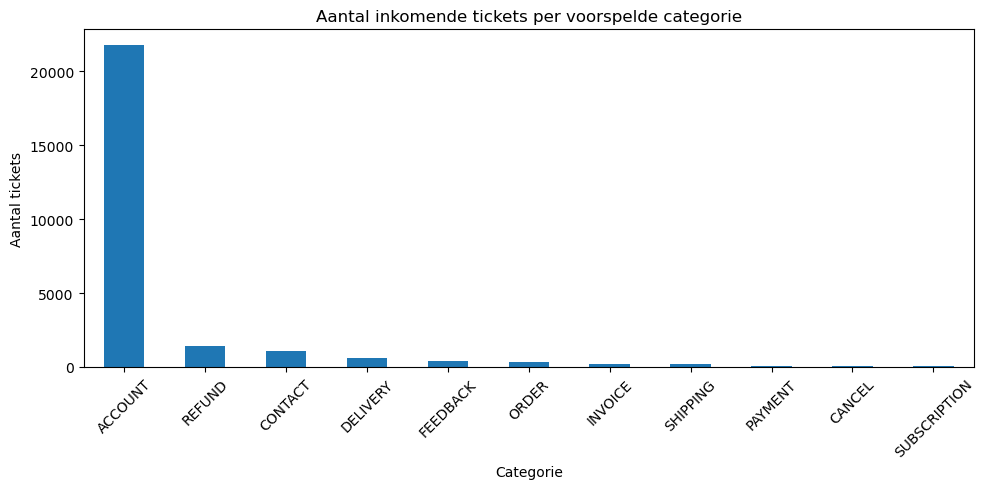

In [80]:
category_counts = twitter_clean["predicted_category"].value_counts()

plt.figure(figsize=(10, 5))
category_counts.plot(kind="bar")
plt.title("Aantal inkomende tickets per voorspelde categorie")
plt.xlabel("Categorie")
plt.ylabel("Aantal tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## monitoring: prioriteiten

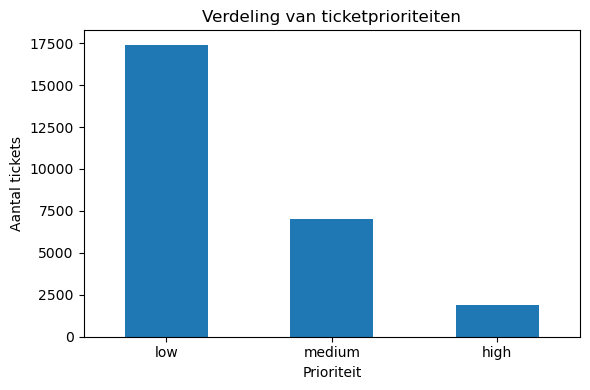

In [81]:
priority_counts = twitter_clean["priority"].value_counts()

plt.figure(figsize=(6, 4))
priority_counts.plot(kind="bar")
plt.title("Verdeling van ticketprioriteiten")
plt.xlabel("Prioriteit")
plt.ylabel("Aantal tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## monitoring: confidence scores

,text,predicted_category,category_confidence
34680,"Fuck you and your ""oops life happens"" reminder...",REFUND,0.126472
33505,"If you have reading plans this weekend, don't ...",ORDER,0.145411
10810,Wells Fargo did me so fucking dirty omg https:...,ACCOUNT,0.145699
34483,@AmazonHelp But that’s not an excuse. You deli...,CONTACT,0.146368
49601,@AppleSupport could you please tell me how do ...,PAYMENT,0.146910
16281,Spotify and Hulu is like the only good thing t...,ACCOUNT,0.149270
38017,@Tesco do you pay for fuel that’s wasted tryin...,FEEDBACK,0.149626
1163,This is the Japanese vampire book I blurbed. D...,ACCOUNT,0.149960
45260,@DunkinDonuts I just received the worst servic...,REFUND,0.150196
28941,You have to do this NOW?! #Windows10 https://t...,CONTACT,0.150749


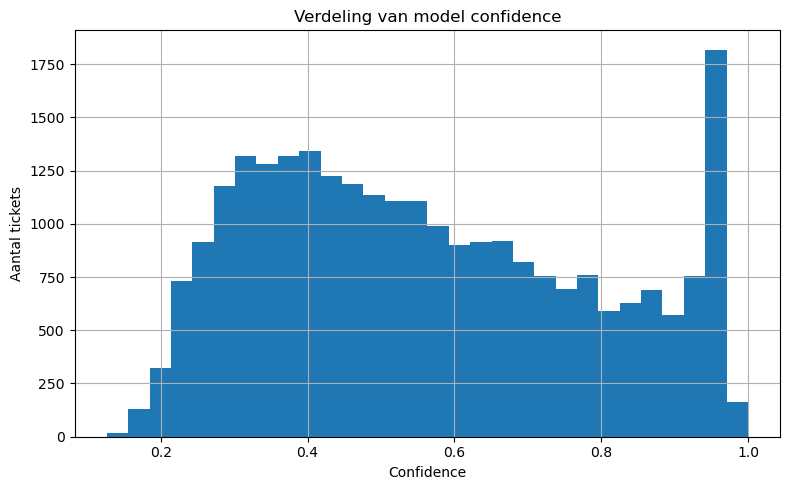

In [82]:
category_probabilities = edge_model.predict_proba(twitter_clean["text_clean"])
twitter_clean["category_confidence"] = category_probabilities.max(axis=1)

display(
    twitter_clean[
        ["text", "predicted_category", "category_confidence"]
    ].sort_values("category_confidence").head(10)
)

plt.figure(figsize=(8, 5))
twitter_clean["category_confidence"].hist(bins=30)
plt.title("Verdeling van model confidence")
plt.xlabel("Confidence")
plt.ylabel("Aantal tickets")
plt.tight_layout()
plt.show()

## drift detectie simpel uitgewerkt

Vergelijk de lengte van trainingsteksten met nieuwe Twittertickets.

In [83]:
train_text_lengths = bitext_clean["text_clean"].str.len()
production_text_lengths = twitter_clean["text_clean"].str.len()

print("Gemiddelde lengte training:", train_text_lengths.mean())
print("Gemiddelde lengte productie:", production_text_lengths.mean())

drift_ratio = production_text_lengths.mean() / train_text_lengths.mean()

print("Drift ratio:", round(drift_ratio, 3))

if drift_ratio < 0.7 or drift_ratio > 1.3:
    print("Waarschuwing: mogelijke datadrift gedetecteerd.")
else:
    print("Geen sterke datadrift gedetecteerd.")

Gemiddelde lengte training: 45.77814152606396
Gemiddelde lengte productie: 92.59682877675958
Drift ratio: 2.023
Waarschuwing: mogelijke datadrift gedetecteerd.


## model opslaan

In [84]:
joblib.dump(edge_model, config.output_dir / "edge_category_model.joblib")
joblib.dump(intent_model, config.output_dir / "edge_intent_model.joblib")

twitter_clean.to_csv(
    config.output_dir / "classified_twitter_tickets.csv",
    index=False
)

print("Modellen en output opgeslagen in:", config.output_dir)

Modellen en output opgeslagen in: flowsure_artifacts


## deploymentvoorbeeld FastAPI

In [85]:
fastapi_example = """
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app = FastAPI()

category_model = joblib.load("flowsure_artifacts/edge_category_model.joblib")
intent_model = joblib.load("flowsure_artifacts/edge_intent_model.joblib")

class TicketRequest(BaseModel):
    text: str

@app.post("/predict")
def predict_ticket(ticket: TicketRequest):
    category = category_model.predict([ticket.text])[0]
    intent = intent_model.predict([ticket.text])[0]
    
    category_confidence = category_model.predict_proba([ticket.text]).max()
    
    return {
        "category": category,
        "intent": intent,
        "confidence": float(category_confidence)
    }
"""

print(fastapi_example)


from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app = FastAPI()

category_model = joblib.load("flowsure_artifacts/edge_category_model.joblib")
intent_model = joblib.load("flowsure_artifacts/edge_intent_model.joblib")

class TicketRequest(BaseModel):
    text: str

@app.post("/predict")
def predict_ticket(ticket: TicketRequest):
    category = category_model.predict([ticket.text])[0]
    intent = intent_model.predict([ticket.text])[0]
    
    category_confidence = category_model.predict_proba([ticket.text]).max()
    
    return {
        "category": category,
        "intent": intent,
        "confidence": float(category_confidence)
    }



## Dockerfile voorbeeld

In [86]:
dockerfile_example = """
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install -r requirements.txt

COPY . .

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

print(dockerfile_example)


FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install -r requirements.txt

COPY . .

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



## requirements voorbeeld

In [87]:
requirements_example = """
fastapi
uvicorn
pandas
scikit-learn
joblib
numpy
"""

print(requirements_example)


fastapi
uvicorn
pandas
scikit-learn
joblib
numpy



## Conclusie

In dit project is een end-to-end MLOps-pipeline ontworpen voor FlowSure. De Bitext Customer Support Dataset is gebruikt om een lichtgewicht edge model te trainen voor ticketclassificatie op categorie en intent. De Twitter Customer Support Dataset is gebruikt als simulatie van inkomende productietickets.

Het edge model gebruikt TF-IDF en Logistic Regression. Deze keuze is passend omdat het model klein, snel, uitlegbaar en geschikt voor deployment is. Het model voorspelt categorieën en intents, waarna tickets automatisch een prioriteit en support squad krijgen toegewezen.

Voor het cloud model is een RAG-achtige aanpak gesimuleerd waarbij historische responses uit de Bitext-dataset worden gebruikt om conceptantwoorden te genereren. In een productieomgeving kan dit worden vervangen door een generatief taalmodel dat relevante kennisbankartikelen gebruikt.

Verder bevat de oplossing monitoring voor ticketvolume, categorieën, prioriteiten, confidence scores en eenvoudige datadrift. De modellen worden opgeslagen als artefacten en kunnen via FastAPI en Docker worden gedeployed.